# PreProcessing & Visualization

### PhDAI 733-A02 — Group Project Part 1
**Group 8:** Prepared by: Harini Mamidala For: Subba Taniparti, Christian Gaston Naveen Vishal Bellary

**Instructor:** Dr. Karriem Perry | **Due:** September 27, 2026

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); sns.set_palette('muted')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


In [20]:
DATA_URL = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df_raw = pd.read_csv(DATA_URL)

print(f"Raw shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"Missing values: {df_raw.isna().sum().sum()}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
df_raw.head()


Raw shape: 303 rows x 14 columns
Missing values: 0
Duplicate rows: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1. Preprocessing

Four decisions, each justified rather than applied by default.


In [22]:
# 2.1 Remove the exact duplicate. A repeated patient record would appear in both
# train and test after splitting, inflating apparent performance.
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {df_raw.shape[0] - df.shape[0]}  ->  {df.shape[0]} patients")

# Apply the corrected label established in Section 1.2
df['disease'] = 1 - df['target']
print(f"Disease prevalence: {df['disease'].mean():.3f} "
      f"({df['disease'].sum()} of {len(df)} patients)")

# 2.2 No imputation is required: the dataset is complete. The hints document suggests
# forward-fill, which would be inappropriate here anyway -- it assumes row order carries
# meaning, and these records are not ordered in any clinically meaningful way.
print(f"Missing values requiring imputation: {df.isna().sum().sum()}")


Duplicates removed: 1  ->  302 patients
Disease prevalence: 0.457 (138 of 302 patients)
Missing values requiring imputation: 0


In [23]:
# 2.3 Encode the categorical codes properly
CATEGORICAL = ['cp', 'restecg', 'slope', 'thal', 'ca']
BINARY      = ['sex', 'fbs', 'exang']
CONTINUOUS  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X = pd.get_dummies(
    df.drop(columns=['target', 'disease']).astype({c: 'category' for c in CATEGORICAL}),
    columns=CATEGORICAL, drop_first=True)
y = df['disease']

print(f"Encoded: {df.shape[1] - 2} predictors -> {X.shape[1]} features")
print(f"Created: {[c for c in X.columns if c not in df.columns]}")


Encoded: 13 predictors -> 22 features
Created: ['cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3', 'ca_1', 'ca_2', 'ca_3', 'ca_4']


**On scaling (a deliberate departure from the assignment hints).** The hints document applies
`StandardScaler` to the full dataset before `train_test_split`. Doing so fits the scaler's means
and standard deviations using test-set rows, leaking information from data the model is supposed
not to have seen and producing optimistic performance estimates.

We instead place the scaler inside a `Pipeline`, so it is fitted only on training folds during
cross-validation and only on the training set for the final fit. Scaling is applied to the five
continuous predictors; the binary and one-hot columns are passed through unchanged, since
standardizing an indicator variable distorts its interpretation without benefit.

This decision was taken by the team and is recorded in `DECISIONS.md` in our repository.


### 1.1 Descriptive statistics and extreme values

The table produced below is reproduced in the written report. The two extremes it exposes —
cholesterol reaching 564 mg/dL and resting blood pressure reaching 200 mm Hg — are checked here
rather than assumed to be data-entry errors.

In [24]:
# Descriptive statistics for the five continuous predictors (reported in the write-up)
desc = df[CONTINUOUS].agg(['mean', 'std', 'min', 'max']).T.round(2)
desc.columns = ['Mean', 'SD', 'Min', 'Max']
print(desc.to_string())

# Are the extreme values plausible patients, or data errors?
print(f"\nPatients with cholesterol > 400 mg/dL: {(df['chol'] > 400).sum()}")
print(f"Patients with resting BP >= 180 mm Hg: {(df['trestbps'] >= 180).sum()}")
print(f"\nDisease rate among the high-cholesterol group: {df.loc[df['chol'] > 400, 'disease'].mean():.3f}")
print(f"Disease rate overall:                          {df['disease'].mean():.3f}")

            Mean     SD    Min    Max
age        54.42   9.05   29.0   77.0
trestbps  131.60  17.56   94.0  200.0
chol      246.50  51.75  126.0  564.0
thalach   149.57  22.90   71.0  202.0
oldpeak     1.04   1.16    0.0    6.2

Patients with cholesterol > 400 mg/dL: 4
Patients with resting BP >= 180 mm Hg: 5

Disease rate among the high-cholesterol group: 0.500
Disease rate overall:                          0.457


**Interpretation.** Both extremes are clinically plausible in a cardiology referral population
rather than transcription errors, so they were retained. Removing them would discard exactly the
high-risk patients a triage tool exists to surface — the opposite of the intended purpose. Scaling,
applied inside the pipeline, limits their leverage on the fitted coefficients without deleting any
patient from the analysis.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"Training: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients")
print(f"Disease prevalence -- train {y_train.mean():.3f}, test {y_test.mean():.3f} (stratified)")

preprocessor = ColumnTransformer([('scale', StandardScaler(), CONTINUOUS)],
                                 remainder='passthrough')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Training: 226 patients | Test: 76 patients
Disease prevalence -- train 0.456, test 0.461 (stratified)


### 1.2 Exploratory visualisation

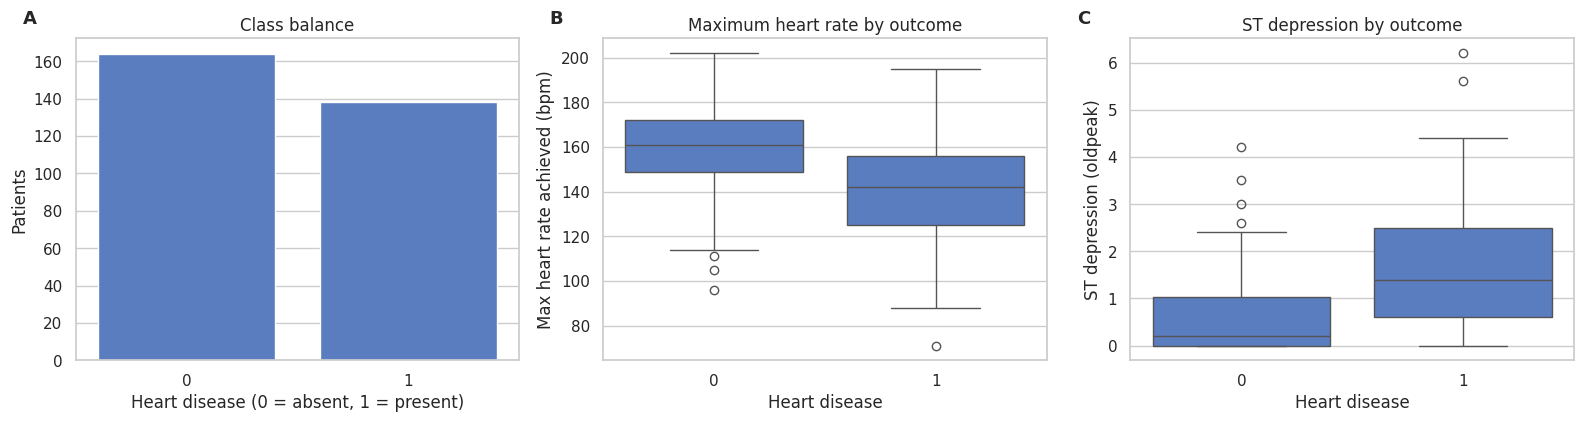

Class balance: {0: 164, 1: 138} (45.7% have disease)
thalach: no disease 158.38, disease 139.10
oldpeak: no disease 0.59, disease 1.59


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

sns.countplot(data=df, x='disease', ax=axes[0])
axes[0].set_title('Class balance'); axes[0].set_xlabel('Heart disease (0 = absent, 1 = present)')
axes[0].set_ylabel('Patients')

sns.boxplot(data=df, x='disease', y='thalach', ax=axes[1])
axes[1].set_title('Maximum heart rate by outcome')
axes[1].set_xlabel('Heart disease'); axes[1].set_ylabel('Max heart rate achieved (bpm)')

sns.boxplot(data=df, x='disease', y='oldpeak', ax=axes[2])
axes[2].set_title('ST depression by outcome')
axes[2].set_xlabel('Heart disease'); axes[2].set_ylabel('ST depression (oldpeak)')

for ax, lab in zip(axes, ['A', 'B', 'C']):
    ax.text(-0.12, 1.09, lab, transform=ax.transAxes, fontsize=13, fontweight='bold', va='top')

plt.tight_layout(); plt.savefig('fig1_eda.png', dpi=130, bbox_inches='tight'); plt.show()

print(f"Class balance: {y.value_counts().to_dict()} ({y.mean():.1%} have disease)")
for c in ['thalach', 'oldpeak']:
    g = df.groupby('disease')[c].mean()
    print(f"{c}: no disease {g[0]:.2f}, disease {g[1]:.2f}")


**Interpretation.** Panel A shows the classes are reasonably balanced (45.7% of patients have
disease), so accuracy is usable as a headline metric and resampling is unnecessary. It remains
insufficient on its own, however: in a triage application a missed case and a false alarm carry very
different costs, so recall and the confusion matrix matter more than a single accuracy figure.

Panels B and C use identical plot types and axis conventions, so the two predictors are directly
comparable. Both separate the classes visibly and in the clinically expected direction: patients
with disease achieve a *lower* maximum heart rate (139.10 vs 158.38 bpm) and show *greater* ST
depression (1.59 vs 0.59). These are the same relationships used in Section 1.2 to establish the
label encoding, and seeing them hold here confirms that correction was applied correctly.

The separation is clear but the distributions overlap substantially, which signals in advance that
no single predictor will suffice and a multivariate model is warranted.


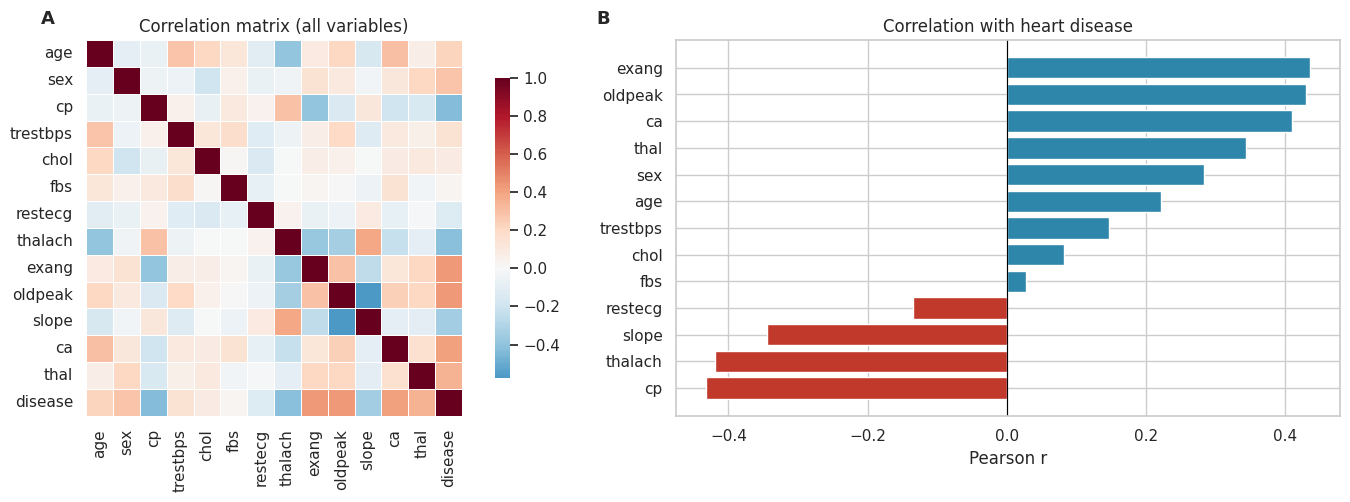

cp         -0.432
thalach    -0.420
slope      -0.344
restecg    -0.135
fbs         0.027
chol        0.081
trestbps    0.146
age         0.221
sex         0.284
thal        0.343
ca          0.409
oldpeak     0.429
exang       0.436


In [27]:
corr = df.drop(columns='target').corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, square=True,
            linewidths=0.4, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation matrix (all variables)')

target_corr = corr['disease'].drop('disease').sort_values()
colors = ['#C0392B' if v < 0 else '#2E86AB' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with heart disease')
axes[1].set_xlabel('Pearson r')

for ax, lab in zip(axes, ['A', 'B']):
    ax.text(-0.12, 1.08, lab, transform=ax.transAxes, fontsize=13, fontweight='bold', va='top')

plt.tight_layout(); plt.savefig('fig2_corr.png', dpi=130, bbox_inches='tight'); plt.show()
print(target_corr.round(3).to_string())


**Interpretation.** Panel B ranks each variable's linear association with disease, and the
ordering is clinically coherent: exercise-induced angina, ST depression, and fluoroscopy vessel
count are the strongest positive correlates of disease, while maximum heart rate and chest pain
type correlate negatively.

Two observations matter for modelling. First, no single predictor exceeds |*r*| = .45, so
performance must come from combining signals rather than from any dominant variable. Second, Panel A
shows no block of near-collinear predictors of the kind that destabilises regression coefficients.
This supports retaining all thirteen predictors rather than pruning.